In [1]:
!unzip /content/drive/MyDrive/gait_data.zip

Archive:  /content/drive/MyDrive/gait_data.zip
   creating: gait_data/
  inflating: gait_data/demographics.txt  
  inflating: gait_data/format.txt    
  inflating: gait_data/GaCo01_01.txt  
  inflating: gait_data/GaCo02_01.txt  
  inflating: gait_data/GaCo02_02.txt  
  inflating: gait_data/GaCo03_01.txt  
  inflating: gait_data/GaCo03_02.txt  
  inflating: gait_data/GaCo04_01.txt  
  inflating: gait_data/GaCo04_02.txt  
  inflating: gait_data/GaCo05_01.txt  
  inflating: gait_data/GaCo05_02.txt  
  inflating: gait_data/GaCo06_01.txt  
  inflating: gait_data/GaCo06_02.txt  
  inflating: gait_data/GaCo07_01.txt  
  inflating: gait_data/GaCo07_02.txt  
  inflating: gait_data/GaCo08_01.txt  
  inflating: gait_data/GaCo08_02.txt  
  inflating: gait_data/GaCo09_01.txt  
  inflating: gait_data/GaCo09_02.txt  
  inflating: gait_data/GaCo10_01.txt  
  inflating: gait_data/GaCo10_02.txt  
  inflating: gait_data/GaCo11_01.txt  
  inflating: gait_data/GaCo12_01.txt  
  inflating: gait_data/GaCo13_

Recent Content

**God Sake** Final Version

Device: cuda
Fixed sequence length: 6000 samples (60s)

Subjects with >= 60s (6000 samples) : 150
  PD       : 88
  Controls : 62
Skipped (< 60s)                        : 8

Processing 150 subjects — first 6000 samples (60s) each...
X_sensors shape : (150, 6000, 16)
X_spec shape    : (150, 32, 32, 16)

Hybrid 1D-CNN + 16-ch Spectrogram (CONVLSTM) — 5-Fold CV

--- Fold 1/5 ---
Train: 120 | Val: 30
  Epoch  10: Train Loss=0.4774 Acc=80.8% | Val Loss=0.5517 Acc=80.0%
  Epoch  20: Train Loss=0.0623 Acc=98.3% | Val Loss=2.7608 Acc=73.3%
  Epoch  30: Train Loss=0.0214 Acc=99.2% | Val Loss=1.6884 Acc=73.3%
  Epoch  40: Train Loss=0.0125 Acc=99.2% | Val Loss=2.3915 Acc=73.3%

  *** Best Val Acc: 83.3% | Corresponding Train Acc: 76.7% ***
  Confusion Matrix:
             PD    Control
        PD     9     3
   Control     2    16

--- Fold 2/5 ---
Train: 120 | Val: 30
  Epoch  10: Train Loss=0.5854 Acc=74.2% | Val Loss=0.5105 Acc=80.0%
  Epoch  20: Train Loss=0.2820 Acc=94.2% | Val Loss=2.5455 

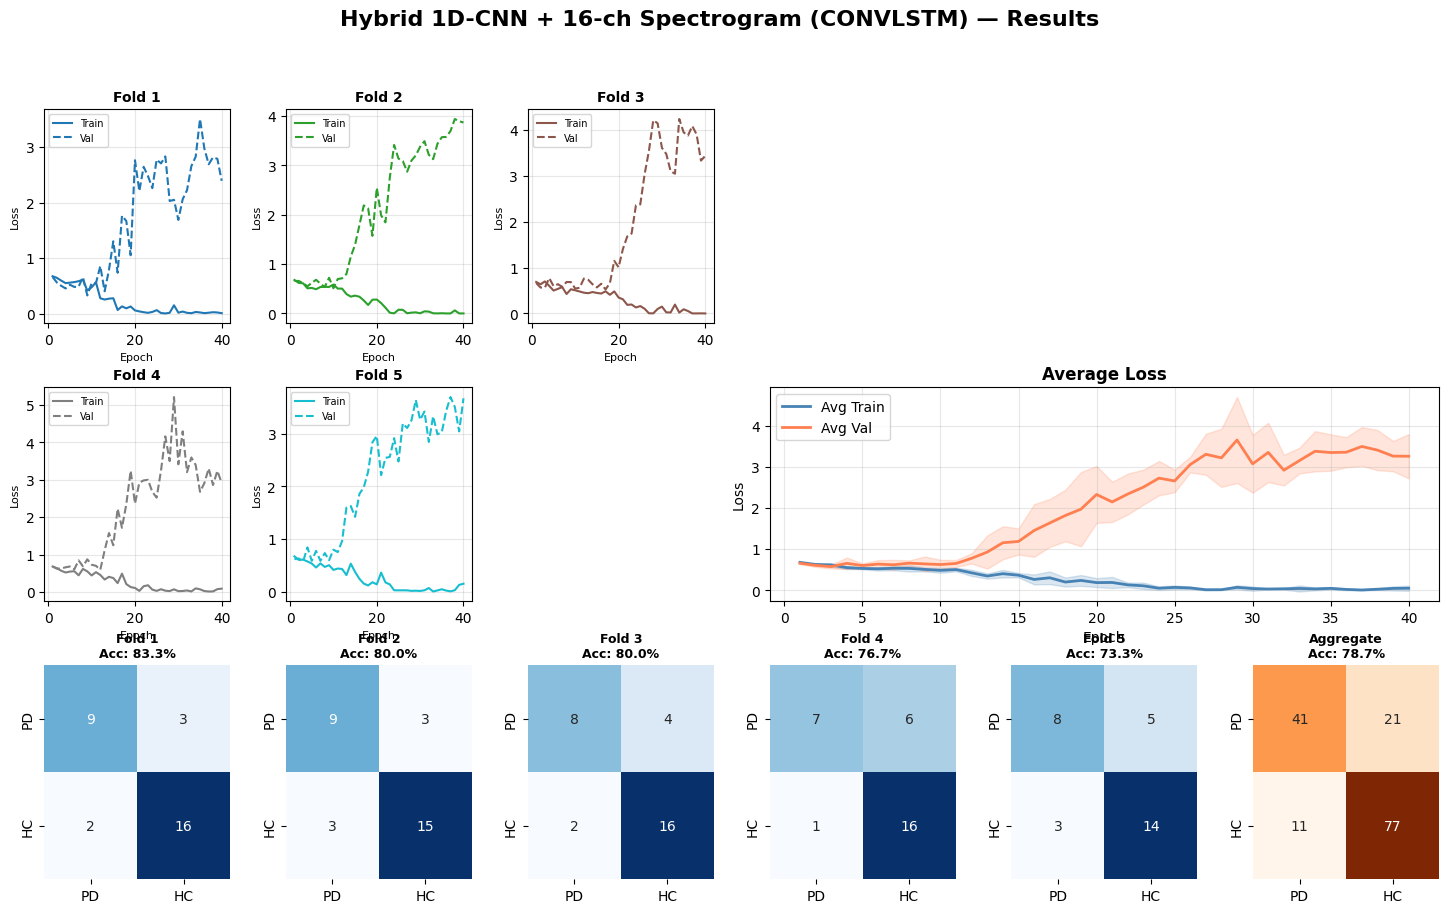


Hybrid 1D-CNN + 16-ch Spectrogram (VIT) — 5-Fold CV

--- Fold 1/5 ---
Train: 120 | Val: 30
  Epoch  10: Train Loss=0.4582 Acc=79.2% | Val Loss=0.6612 Acc=70.0%
  Epoch  20: Train Loss=0.3739 Acc=88.3% | Val Loss=1.2764 Acc=73.3%
  Epoch  30: Train Loss=0.1891 Acc=93.3% | Val Loss=1.2667 Acc=66.7%
  Epoch  40: Train Loss=0.1070 Acc=95.8% | Val Loss=2.1459 Acc=70.0%

  *** Best Val Acc: 83.3% | Corresponding Train Acc: 74.2% ***
  Confusion Matrix:
             PD    Control
        PD     8     4
   Control     1    17

--- Fold 2/5 ---
Train: 120 | Val: 30
  Epoch  10: Train Loss=0.4392 Acc=80.8% | Val Loss=0.9453 Acc=80.0%
  Epoch  20: Train Loss=0.4611 Acc=90.0% | Val Loss=0.5708 Acc=80.0%
  Epoch  30: Train Loss=0.1529 Acc=96.7% | Val Loss=0.9660 Acc=83.3%
  Epoch  40: Train Loss=0.1298 Acc=97.5% | Val Loss=2.7628 Acc=70.0%

  *** Best Val Acc: 86.7% | Corresponding Train Acc: 83.3% ***
  Confusion Matrix:
             PD    Control
        PD    10     2
   Control     2    16

--

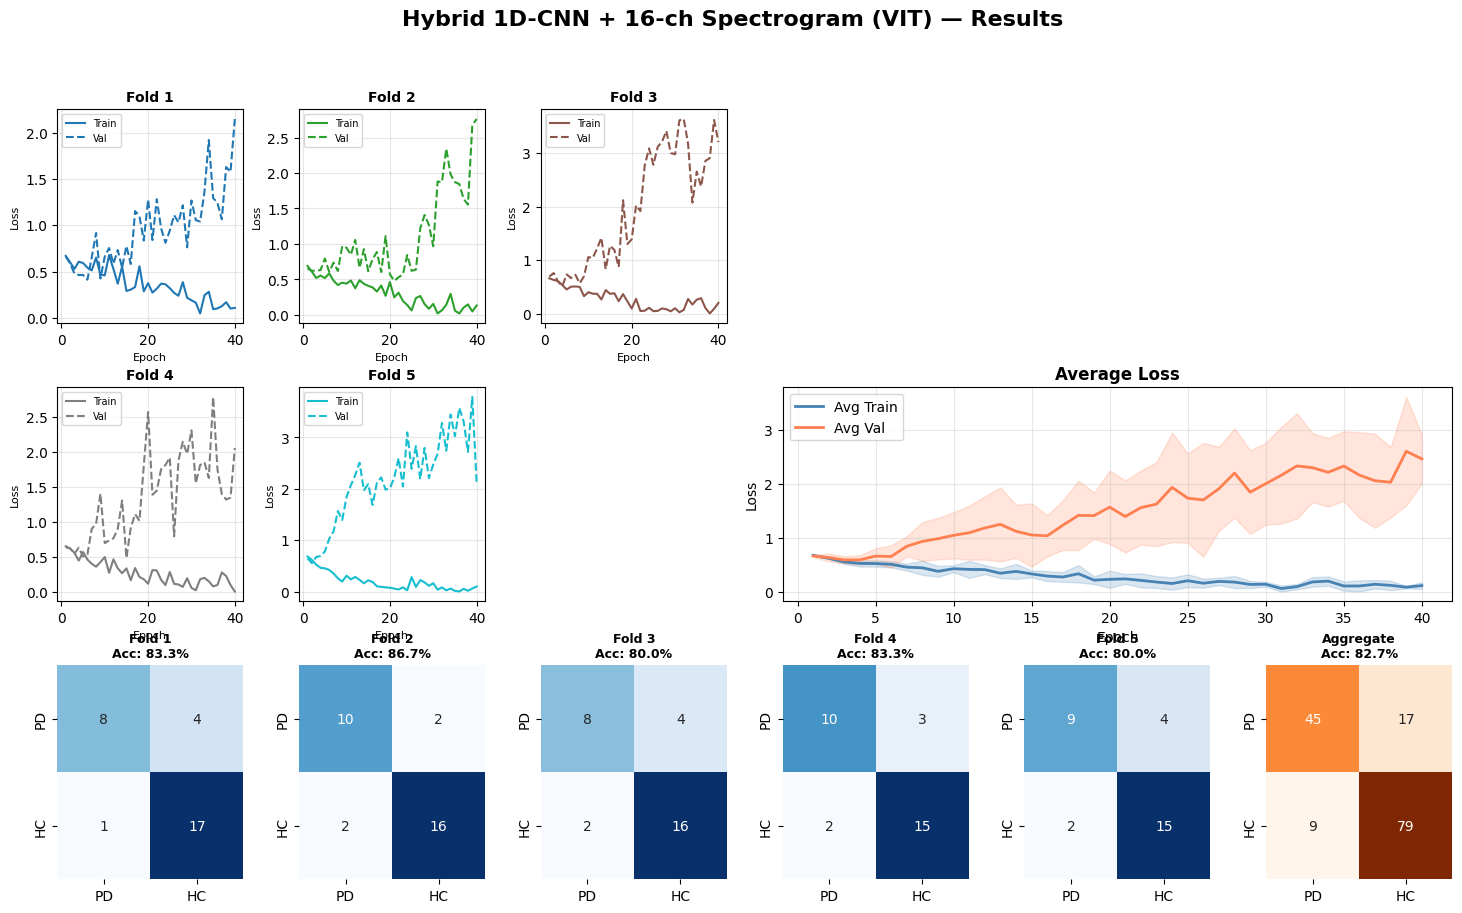

In [ ]:
# ============================================================
# Hybrid Gait PD Classification
# Pipeline 1: 16 VGRF sensors → 1D-CNN  (unchanged)
# Pipeline 2: 16 individual sensor spectrograms → 16-channel → ConvLSTM2D/ViT/FlipFlop2D
# Concatenate → Fully Connected → Classification
# 5-Fold CV | Best acc per fold | Confusion matrices
# Only subjects with >= 60s recordings (6000 samples at 100 Hz)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.ndimage import zoom
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR    = 'gait_data'
SAVE_DIR    = Path("gait_hybrid_16ch_models_new")
SAVE_DIR.mkdir(exist_ok=True)

N_FOLDS     = 5
BATCH_SIZE  = 4
EPOCHS      = 40
LR          = 0.001
FS          = 100                  # sampling frequency
MIN_SECS    = 60                   # minimum recording duration
MAX_LENGTH  = MIN_SECS * FS        # 6000 samples — fixed length, no padding needed
N_SENSORS   = 16
SPEC_SIZE   = 32
N_TIME      = 32
N_FREQ      = 32
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"Fixed sequence length: {MAX_LENGTH} samples ({MIN_SECS}s)")
torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# DATA LOADING  — only keep subjects with >= 6000 samples
# ============================================================
def load_data(data_dir=DATA_DIR):
    demographics = pd.read_csv(f'{data_dir}/demographics.txt',
                               sep='\t', on_bad_lines='skip')
    demographics = demographics.dropna(subset=['ID'])  # drop empty trailing rows

    subjects, labels = [], []
    skipped = 0

    for idx, row in demographics.iterrows():
        subject_id = row['ID']
        group      = row['Group']
        filepath   = f"{data_dir}/{subject_id}_01.txt"

        if Path(filepath).exists():
            try:
                data = pd.read_csv(filepath, sep='\t', header=None).values
                if len(data) >= MAX_LENGTH:
                    subjects.append({'id': subject_id, 'data': data})
                    labels.append(1 if group == 1 else 0)  # 1=PD, 0=Control
                else:
                    skipped += 1
            except Exception as e:
                print(f"  [ERROR] {subject_id}: {e}")
                continue

    print(f"\nSubjects with >= {MIN_SECS}s ({MAX_LENGTH} samples) : {len(subjects)}")
    print(f"  PD       : {sum(labels)}")
    print(f"  Controls : {len(labels) - sum(labels)}")
    print(f"Skipped (< {MIN_SECS}s)                        : {skipped}")
    return subjects, np.array(labels)


# ============================================================
# DATA PROCESSING
# ============================================================
def create_spectrogram(sensor_signal, fs=FS, target_size=SPEC_SIZE):
    nperseg  = 64
    f, t, Sxx = signal.spectrogram(sensor_signal, fs=fs,
                                    nperseg=nperseg, noverlap=nperseg // 2)
    Sxx_db   = 10 * np.log10(Sxx + 1e-10)
    freq_mask = f <= 10
    Sxx_db   = Sxx_db[freq_mask, :]
    zoom_factors = (target_size / Sxx_db.shape[0],
                    target_size / Sxx_db.shape[1])
    return zoom(Sxx_db, zoom_factors, order=1)   # (32, 32)


def process_subject(subject_data, max_length=MAX_LENGTH, spec_size=SPEC_SIZE):
    """
    All subjects are >= max_length — just take the first max_length samples.
    No padding required.
      sensors_16   : (max_length, 16)
      spectrograms : (spec_size, spec_size, 16)
    """
    data = subject_data[:max_length]             # ← truncate to exactly 6000, no padding

    sensors_16 = data[:, 1:17].astype(np.float32)   # (6000, 16)

    specs = []
    for s in range(N_SENSORS):
        spec = create_spectrogram(data[:, s + 1], target_size=spec_size)
        specs.append(spec)

    spectrograms = np.stack(specs, axis=-1).astype(np.float32)   # (32, 32, 16)

    return sensors_16, spectrograms


class GaitDataset(Dataset):
    def __init__(self, X_sensors, X_spec, y):
        self.X_sensors = torch.FloatTensor(X_sensors)
        self.X_spec    = torch.FloatTensor(X_spec)
        self.y         = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_sensors[idx], self.X_spec[idx], self.y[idx]


# ============================================================
# MODEL COMPONENTS
# ============================================================

class SensorCNN(nn.Module):
    def __init__(self, n_sensors=N_SENSORS):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_sensors, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Dropout(0.15)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv3(x)
        return x.squeeze(-1)   # (batch, 128)


class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(in_channels + hidden_channels,
                              4 * hidden_channels,
                              kernel_size, padding=kernel_size // 2)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c_prev + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        c_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t, c_t = self.cell(x[:, t], h_t, c_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.convlstm1 = ConvLSTM2D(N_SENSORS, 32, kernel_size=3, return_sequences=True)
        self.drop1     = nn.Dropout(0.15)
        self.convlstm2 = ConvLSTM2D(32, 16, kernel_size=3, return_sequences=False)
        self.drop2     = nn.Dropout(0.15)
        self.fc        = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.convlstm1(x))
        x = self.drop2(self.convlstm2(x))
        return self.fc(x)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        p = kernel_size // 2
        self.conv_xj = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hj = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)
        self.conv_xk = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hk = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)

    def forward(self, x, h_prev):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h_prev))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h_prev))
        return (1 - h_prev) * j + (1 - k) * h_prev


class FlipFlop2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = FlipFlopCell2D(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t = self.cell(x[:, t], h_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramFlipFlop(nn.Module):
    def __init__(self):
        super().__init__()
        self.ff1   = FlipFlop2D(N_SENSORS, 64, kernel_size=3, return_sequences=True)
        self.drop1 = nn.Dropout(0.15)
        self.ff2   = FlipFlop2D(64, 32, kernel_size=3, return_sequences=False)
        self.drop2 = nn.Dropout(0.15)
        self.fc    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.ff1(x))
        x = self.drop2(self.ff2(x))
        return self.fc(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class SpectrogramViT(nn.Module):
    def __init__(self, img_size=(N_TIME, N_FREQ), patch_size=4,
                 dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nt, nf    = img_size
        n_patches = (nt // patch_size) * (nf // patch_size)
        self.proj      = nn.Conv2d(N_SENSORS, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(nn.Linear(dim, 64), nn.ReLU())
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x   = x.permute(0, 3, 1, 2)
        x   = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed
        x   = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))


class HybridModel(nn.Module):
    def __init__(self, spec_model_type='convlstm'):
        super().__init__()
        self.sensor_cnn = SensorCNN()
        if spec_model_type == 'convlstm':
            self.spec_model = SpectrogramConvLSTM()
        elif spec_model_type == 'flipflop':
            self.spec_model = SpectrogramFlipFlop()
        elif spec_model_type == 'vit':
            self.spec_model = SpectrogramViT()
        else:
            raise ValueError(f"Unknown model type: {spec_model_type}")

        self.fusion = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 2)
        )

    def forward(self, x_sensors, x_spec):
        feat_sensors = self.sensor_cnn(x_sensors)
        feat_spec    = self.spec_model(x_spec)
        return self.fusion(torch.cat([feat_sensors, feat_spec], dim=1))


# ============================================================
# TRAINING FUNCTIONS
# ============================================================
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x_sensors, x_spec, yb in loader:
        x_sensors, x_spec, yb = x_sensors.to(DEVICE), x_spec.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x_sensors, x_spec)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return total_loss / len(loader), 100.0 * correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for x_sensors, x_spec, yb in loader:
            x_sensors, x_spec, yb = x_sensors.to(DEVICE), x_spec.to(DEVICE), yb.to(DEVICE)
            out  = model(x_sensors, x_spec)
            loss = criterion(out, yb)
            total_loss  += loss.item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


# ============================================================
# 5-FOLD CV
# ============================================================
def train_5fold(X_sensors, X_spec, y, model_type):
    print(f"\n{'='*65}")
    print(f"Hybrid 1D-CNN + 16-ch Spectrogram ({model_type.upper()}) — 5-Fold CV")
    print(f"{'='*65}")

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_train_losses, fold_val_losses = [], []
    fold_metrics, all_preds, all_labels = [], [], []

    model_dir = SAVE_DIR / model_type
    model_dir.mkdir(exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_sensors, y)):
        print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

        X_sensors_train, X_sensors_val = X_sensors[train_idx], X_sensors[val_idx]
        X_spec_train,    X_spec_val    = X_spec[train_idx],    X_spec[val_idx]
        y_train, y_val                 = y[train_idx],         y[val_idx]
        print(f"Train: {len(y_train)} | Val: {len(y_val)}")

        mean_s = X_sensors_train.mean(axis=(0, 1), keepdims=True)
        std_s  = X_sensors_train.std(axis=(0, 1),  keepdims=True) + 1e-8
        X_sensors_train = (X_sensors_train - mean_s) / std_s
        X_sensors_val   = (X_sensors_val   - mean_s) / std_s

        mean_spec = X_spec_train.mean(axis=(0, 1, 2), keepdims=True)
        std_spec  = X_spec_train.std(axis=(0, 1, 2),  keepdims=True) + 1e-8
        X_spec_train = (X_spec_train - mean_spec) / std_spec
        X_spec_val   = (X_spec_val   - mean_spec) / std_spec

        fold_data = {
            'test_indices':  val_idx,
            'X_sensors_val': X_sensors_val,
            'X_spec_val':    X_spec_val,
            'y_val':         y_val,
            'sensor_mean':   mean_s,   'sensor_std': std_s,
            'spec_mean':     mean_spec, 'spec_std':  std_spec
        }
        with open(model_dir / f"fold{fold+1}_test_data.pkl", 'wb') as f:
            pickle.dump(fold_data, f)

        train_loader = DataLoader(GaitDataset(X_sensors_train, X_spec_train, y_train),
                                  batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(GaitDataset(X_sensors_val,   X_spec_val,   y_val),
                                  batch_size=BATCH_SIZE)

        model     = HybridModel(spec_model_type=model_type).to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

        best_val_acc, best_train_acc, best_preds, best_labels = 0.0, 0.0,None, None
        train_losses, val_losses = [], []

        for epoch in range(EPOCHS):
            tr_loss, tr_acc         = train_epoch(model, train_loader, criterion, optimizer)
            val_loss, preds, labels = eval_epoch(model, val_loader, criterion)
            val_acc                 = accuracy_score(labels, preds)
            train_losses.append(tr_loss)
            val_losses.append(val_loss)

            if val_acc > best_val_acc:
              best_val_acc, best_train_acc, best_preds, best_labels = val_acc, tr_acc, preds, labels
              torch.save(model.state_dict(), model_dir / f"fold{fold+1}_best.pth")
              with open(model_dir / f"fold{fold+1}_predictions.pkl", 'wb') as f:
                    pickle.dump({'predictions': best_preds, 'true_labels': best_labels}, f)

            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:3d}: Train Loss={tr_loss:.4f} Acc={tr_acc:.1f}% | "
                      f"Val Loss={val_loss:.4f} Acc={val_acc*100:.1f}%")

        torch.save(model.state_dict(), model_dir / f"fold{fold+1}_last.pth")
        print(f"\n  *** Best Val Acc: {best_val_acc*100:.1f}% | Corresponding Train Acc: {best_train_acc:.1f}% ***")
        cm = confusion_matrix(best_labels, best_preds)
        print(f"  Confusion Matrix:\n             PD    Control")
        print(f"        PD  {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"   Control  {cm[1,0]:4d}  {cm[1,1]:4d}")

        fold_train_losses.append(train_losses)
        fold_val_losses.append(val_losses)
        fold_metrics.append({
            'acc':  best_val_acc,
            'prec': precision_score(best_labels, best_preds, zero_division=0),
            'rec':  recall_score(best_labels, best_preds,    zero_division=0),
            'f1':   f1_score(best_labels, best_preds,        zero_division=0)
        })
        all_preds.extend(best_preds)
        all_labels.extend(best_labels)

    return {
        'train_losses': fold_train_losses,
        'val_losses':   fold_val_losses,
        'metrics':      fold_metrics,
        'all_preds':    np.array(all_preds),
        'all_labels':   np.array(all_labels)
    }


# ============================================================
# SUMMARY + VISUALIZATION
# ============================================================
def print_summary(results, model_type):
    print(f"\n{'='*55}")
    print(f"Hybrid 16-ch ({model_type.upper()}) Summary")
    print(f"{'='*55}")
    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for i, m in enumerate(results['metrics']):
        print(f"  {i+1:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")
    accs = [m['acc'] for m in results['metrics']]
    prec = [m['prec'] for m in results['metrics']]
    rec  = [m['rec']  for m in results['metrics']]
    f1s  = [m['f1']   for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(prec)*100:>7.1f}% "
          f"{np.mean(rec)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}%  {np.std(prec)*100:>7.1f}%  "
          f"{np.std(rec)*100:>7.1f}%  {np.std(f1s)*100:>7.1f}%")


def plot_results(results, model_type, y):
    fig = plt.figure(figsize=(18, 10))
    gs  = fig.add_gridspec(3, 6, hspace=0.3, wspace=0.3)
    fig.suptitle(f'Hybrid 1D-CNN + 16-ch Spectrogram ({model_type.upper()}) — Results',
                 fontsize=16, fontweight='bold')
    colors = plt.cm.tab10(np.linspace(0, 1, N_FOLDS))

    for fold in range(N_FOLDS):
        ax = fig.add_subplot(gs[fold // 3, fold % 3])
        ep = range(1, EPOCHS + 1)
        ax.plot(ep, results['train_losses'][fold], label='Train', color=colors[fold])
        ax.plot(ep, results['val_losses'][fold],   label='Val',   color=colors[fold], linestyle='--')
        ax.set_title(f'Fold {fold+1}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Epoch', fontsize=8); ax.set_ylabel('Loss', fontsize=8)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 3:])
    ep = range(1, EPOCHS + 1)
    avg_tr = np.mean(results['train_losses'], axis=0)
    avg_vl = np.mean(results['val_losses'],   axis=0)
    std_tr = np.std(results['train_losses'],  axis=0)
    std_vl = np.std(results['val_losses'],    axis=0)
    ax.plot(ep, avg_tr, label='Avg Train', color='steelblue', linewidth=2)
    ax.plot(ep, avg_vl, label='Avg Val',   color='coral',     linewidth=2)
    ax.fill_between(ep, avg_tr-std_tr, avg_tr+std_tr, alpha=0.2, color='steelblue')
    ax.fill_between(ep, avg_vl-std_vl, avg_vl+std_vl, alpha=0.2, color='coral')
    ax.set_title('Average Loss', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)

    skf, start = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42), 0
    for fold, (_, val_idx) in enumerate(skf.split(y, y)):
        ax  = fig.add_subplot(gs[2, fold])
        end = start + len(val_idx)
        cm  = confusion_matrix(results['all_labels'][start:end], results['all_preds'][start:end])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
        ax.set_title(f"Fold {fold+1}\nAcc: {results['metrics'][fold]['acc']*100:.1f}%",
                     fontsize=9, fontweight='bold')
        start = end

    ax     = fig.add_subplot(gs[2, 5])
    cm_all = confusion_matrix(results['all_labels'], results['all_preds'])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    ax.set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%", fontsize=9, fontweight='bold')

    plt.savefig(SAVE_DIR / f'{model_type}_results.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    subjects, y = load_data()

    print(f"\nProcessing {len(subjects)} subjects — first {MAX_LENGTH} samples ({MIN_SECS}s) each...")
    X_sensors_list, X_spec_list = [], []
    for s in subjects:
        sensors, specs = process_subject(s['data'])
        X_sensors_list.append(sensors)
        X_spec_list.append(specs)

    X_sensors = np.stack(X_sensors_list, axis=0)   # (N, 6000, 16)
    X_spec    = np.stack(X_spec_list,    axis=0)   # (N, 32, 32, 16)

    print(f"X_sensors shape : {X_sensors.shape}")
    print(f"X_spec shape    : {X_spec.shape}")

    for model_type in ['convlstm', 'vit']:
        results = train_5fold(X_sensors, X_spec, y, model_type)
        print_summary(results, model_type)
        plot_results(results, model_type, y)

Device: cuda
Fixed sequence length: 6000 samples (60s)

Subjects with >= 60s (6000 samples) : 150
  PD       : 88
  Controls : 62
Skipped (< 60s)                        : 8

Processing 150 subjects — first 6000 samples (60s) each...
X_sensors shape : (150, 6000, 16)
X_spec shape    : (150, 32, 32, 16)

Hybrid 1D-CNN + 16-ch Spectrogram (FLIPFLOP) — 5-Fold CV

--- Fold 1/5 ---
Train: 120 | Val: 30
  Epoch  10: Train Loss=0.5953 Acc=75.8% | Val Loss=0.4106 Acc=83.3%
  Epoch  20: Train Loss=0.5212 Acc=75.0% | Val Loss=0.5615 Acc=83.3%
  Epoch  30: Train Loss=0.4809 Acc=84.2% | Val Loss=0.6906 Acc=80.0%
  Epoch  40: Train Loss=0.5059 Acc=80.0% | Val Loss=0.5343 Acc=83.3%
  Epoch  50: Train Loss=0.4917 Acc=87.5% | Val Loss=0.8882 Acc=80.0%
  Epoch  60: Train Loss=0.2583 Acc=90.0% | Val Loss=0.3788 Acc=93.3%
  Epoch  70: Train Loss=0.3686 Acc=87.5% | Val Loss=0.7881 Acc=83.3%
  Epoch  80: Train Loss=0.3910 Acc=89.2% | Val Loss=0.6163 Acc=80.0%

  *** Best Val Acc: 93.3% | Corresponding Train

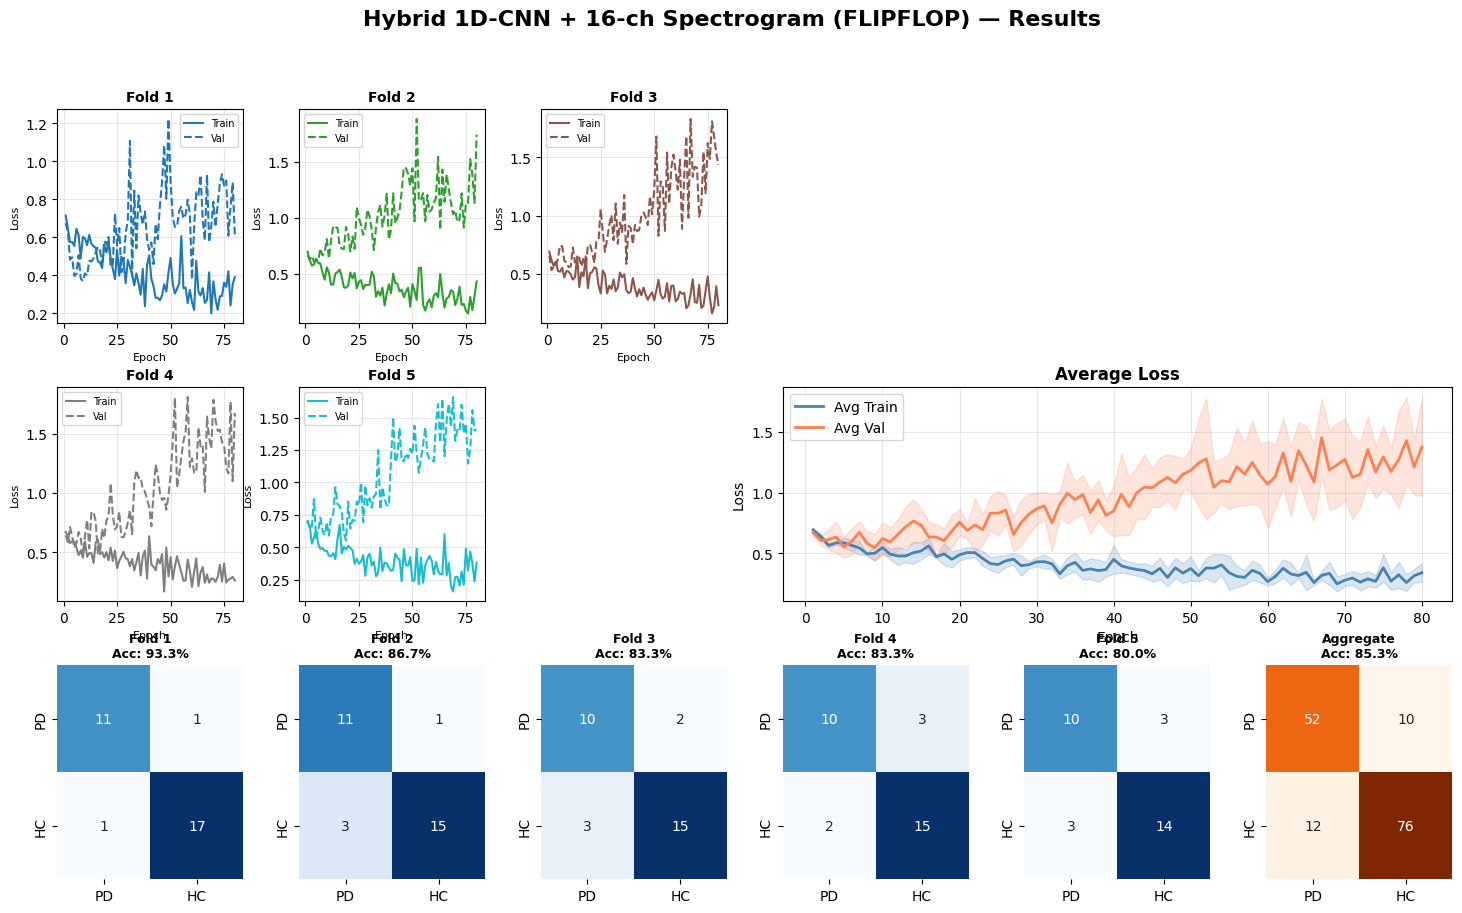

In [ ]:
# ============================================================
# Hybrid Gait PD Classification
# Pipeline 1: 16 VGRF sensors → 1D-CNN  (unchanged)
# Pipeline 2: 16 individual sensor spectrograms → 16-channel → ConvLSTM2D/ViT/FlipFlop2D
# Concatenate → Fully Connected → Classification
# 5-Fold CV | Best acc per fold | Confusion matrices
# Only subjects with >= 60s recordings (6000 samples at 100 Hz)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.ndimage import zoom
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR    = 'gait_data'
SAVE_DIR    = Path("gait_hybrid_16ch_models_new")
SAVE_DIR.mkdir(exist_ok=True)

N_FOLDS     = 5
BATCH_SIZE  = 4
EPOCHS      = 80
LR          = 0.001
FS          = 100                  # sampling frequency
MIN_SECS    = 60                   # minimum recording duration
MAX_LENGTH  = MIN_SECS * FS        # 6000 samples — fixed length, no padding needed
N_SENSORS   = 16
SPEC_SIZE   = 32
N_TIME      = 32
N_FREQ      = 32
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"Fixed sequence length: {MAX_LENGTH} samples ({MIN_SECS}s)")
torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# DATA LOADING  — only keep subjects with >= 6000 samples
# ============================================================
def load_data(data_dir=DATA_DIR):
    demographics = pd.read_csv(f'{data_dir}/demographics.txt',
                               sep='\t', on_bad_lines='skip')
    demographics = demographics.dropna(subset=['ID'])  # drop empty trailing rows

    subjects, labels = [], []
    skipped = 0

    for idx, row in demographics.iterrows():
        subject_id = row['ID']
        group      = row['Group']
        filepath   = f"{data_dir}/{subject_id}_01.txt"

        if Path(filepath).exists():
            try:
                data = pd.read_csv(filepath, sep='\t', header=None).values
                if len(data) >= MAX_LENGTH:
                    subjects.append({'id': subject_id, 'data': data})
                    labels.append(1 if group == 1 else 0)  # 1=PD, 0=Control
                else:
                    skipped += 1
            except Exception as e:
                print(f"  [ERROR] {subject_id}: {e}")
                continue

    print(f"\nSubjects with >= {MIN_SECS}s ({MAX_LENGTH} samples) : {len(subjects)}")
    print(f"  PD       : {sum(labels)}")
    print(f"  Controls : {len(labels) - sum(labels)}")
    print(f"Skipped (< {MIN_SECS}s)                        : {skipped}")
    return subjects, np.array(labels)


# ============================================================
# DATA PROCESSING
# ============================================================
def create_spectrogram(sensor_signal, fs=FS, target_size=SPEC_SIZE):
    nperseg  = 64
    f, t, Sxx = signal.spectrogram(sensor_signal, fs=fs,
                                    nperseg=nperseg, noverlap=nperseg // 2)
    Sxx_db   = 10 * np.log10(Sxx + 1e-10)
    freq_mask = f <= 10
    Sxx_db   = Sxx_db[freq_mask, :]
    zoom_factors = (target_size / Sxx_db.shape[0],
                    target_size / Sxx_db.shape[1])
    return zoom(Sxx_db, zoom_factors, order=1)   # (32, 32)


def process_subject(subject_data, max_length=MAX_LENGTH, spec_size=SPEC_SIZE):
    """
    All subjects are >= max_length — just take the first max_length samples.
    No padding required.
      sensors_16   : (max_length, 16)
      spectrograms : (spec_size, spec_size, 16)
    """
    data = subject_data[:max_length]             # ← truncate to exactly 6000, no padding

    sensors_16 = data[:, 1:17].astype(np.float32)   # (6000, 16)

    specs = []
    for s in range(N_SENSORS):
        spec = create_spectrogram(data[:, s + 1], target_size=spec_size)
        specs.append(spec)

    spectrograms = np.stack(specs, axis=-1).astype(np.float32)   # (32, 32, 16)

    return sensors_16, spectrograms


class GaitDataset(Dataset):
    def __init__(self, X_sensors, X_spec, y):
        self.X_sensors = torch.FloatTensor(X_sensors)
        self.X_spec    = torch.FloatTensor(X_spec)
        self.y         = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_sensors[idx], self.X_spec[idx], self.y[idx]


# ============================================================
# MODEL COMPONENTS
# ============================================================

class SensorCNN(nn.Module):
    def __init__(self, n_sensors=N_SENSORS):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_sensors, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Dropout(0.15)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv3(x)
        return x.squeeze(-1)   # (batch, 128)


class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(in_channels + hidden_channels,
                              4 * hidden_channels,
                              kernel_size, padding=kernel_size // 2)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c_prev + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        c_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t, c_t = self.cell(x[:, t], h_t, c_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.convlstm1 = ConvLSTM2D(N_SENSORS, 32, kernel_size=3, return_sequences=True)
        self.drop1     = nn.Dropout(0.15)
        self.convlstm2 = ConvLSTM2D(32, 16, kernel_size=3, return_sequences=False)
        self.drop2     = nn.Dropout(0.15)
        self.fc        = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.convlstm1(x))
        x = self.drop2(self.convlstm2(x))
        return self.fc(x)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        p = kernel_size // 2
        self.conv_xj = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hj = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)
        self.conv_xk = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hk = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)

    def forward(self, x, h_prev):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h_prev))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h_prev))
        return (1 - h_prev) * j + (1 - k) * h_prev


class FlipFlop2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = FlipFlopCell2D(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t = self.cell(x[:, t], h_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramFlipFlop(nn.Module):
    def __init__(self):
        super().__init__()
        self.ff1   = FlipFlop2D(N_SENSORS, 64, kernel_size=3, return_sequences=True)
        self.drop1 = nn.Dropout(0.15)
        self.ff2   = FlipFlop2D(64, 32, kernel_size=3, return_sequences=False)
        self.drop2 = nn.Dropout(0.15)
        self.fc    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.ff1(x))
        x = self.drop2(self.ff2(x))
        return self.fc(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class SpectrogramViT(nn.Module):
    def __init__(self, img_size=(N_TIME, N_FREQ), patch_size=4,
                 dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nt, nf    = img_size
        n_patches = (nt // patch_size) * (nf // patch_size)
        self.proj      = nn.Conv2d(N_SENSORS, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(nn.Linear(dim, 64), nn.ReLU())
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x   = x.permute(0, 3, 1, 2)
        x   = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed
        x   = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))


class HybridModel(nn.Module):
    def __init__(self, spec_model_type='convlstm'):
        super().__init__()
        self.sensor_cnn = SensorCNN()
        if spec_model_type == 'convlstm':
            self.spec_model = SpectrogramConvLSTM()
        elif spec_model_type == 'flipflop':
            self.spec_model = SpectrogramFlipFlop()
        elif spec_model_type == 'vit':
            self.spec_model = SpectrogramViT()
        else:
            raise ValueError(f"Unknown model type: {spec_model_type}")

        self.fusion = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 2)
        )

    def forward(self, x_sensors, x_spec):
        feat_sensors = self.sensor_cnn(x_sensors)
        feat_spec    = self.spec_model(x_spec)
        return self.fusion(torch.cat([feat_sensors, feat_spec], dim=1))


# ============================================================
# TRAINING FUNCTIONS
# ============================================================
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x_sensors, x_spec, yb in loader:
        x_sensors, x_spec, yb = x_sensors.to(DEVICE), x_spec.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x_sensors, x_spec)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return total_loss / len(loader), 100.0 * correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for x_sensors, x_spec, yb in loader:
            x_sensors, x_spec, yb = x_sensors.to(DEVICE), x_spec.to(DEVICE), yb.to(DEVICE)
            out  = model(x_sensors, x_spec)
            loss = criterion(out, yb)
            total_loss  += loss.item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


# ============================================================
# 5-FOLD CV
# ============================================================
def train_5fold(X_sensors, X_spec, y, model_type):
    print(f"\n{'='*65}")
    print(f"Hybrid 1D-CNN + 16-ch Spectrogram ({model_type.upper()}) — 5-Fold CV")
    print(f"{'='*65}")

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_train_losses, fold_val_losses = [], []
    fold_metrics, all_preds, all_labels = [], [], []

    model_dir = SAVE_DIR / model_type
    model_dir.mkdir(exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_sensors, y)):
        print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

        X_sensors_train, X_sensors_val = X_sensors[train_idx], X_sensors[val_idx]
        X_spec_train,    X_spec_val    = X_spec[train_idx],    X_spec[val_idx]
        y_train, y_val                 = y[train_idx],         y[val_idx]
        print(f"Train: {len(y_train)} | Val: {len(y_val)}")

        mean_s = X_sensors_train.mean(axis=(0, 1), keepdims=True)
        std_s  = X_sensors_train.std(axis=(0, 1),  keepdims=True) + 1e-8
        X_sensors_train = (X_sensors_train - mean_s) / std_s
        X_sensors_val   = (X_sensors_val   - mean_s) / std_s

        mean_spec = X_spec_train.mean(axis=(0, 1, 2), keepdims=True)
        std_spec  = X_spec_train.std(axis=(0, 1, 2),  keepdims=True) + 1e-8
        X_spec_train = (X_spec_train - mean_spec) / std_spec
        X_spec_val   = (X_spec_val   - mean_spec) / std_spec

        fold_data = {
            'test_indices':  val_idx,
            'X_sensors_val': X_sensors_val,
            'X_spec_val':    X_spec_val,
            'y_val':         y_val,
            'sensor_mean':   mean_s,   'sensor_std': std_s,
            'spec_mean':     mean_spec, 'spec_std':  std_spec
        }
        with open(model_dir / f"fold{fold+1}_test_data.pkl", 'wb') as f:
            pickle.dump(fold_data, f)

        train_loader = DataLoader(GaitDataset(X_sensors_train, X_spec_train, y_train),
                                  batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(GaitDataset(X_sensors_val,   X_spec_val,   y_val),
                                  batch_size=BATCH_SIZE)

        model     = HybridModel(spec_model_type=model_type).to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

        best_val_acc, best_train_acc, best_preds, best_labels = 0.0, 0.0,None, None
        train_losses, val_losses = [], []

        for epoch in range(EPOCHS):
            tr_loss, tr_acc         = train_epoch(model, train_loader, criterion, optimizer)
            val_loss, preds, labels = eval_epoch(model, val_loader, criterion)
            val_acc                 = accuracy_score(labels, preds)
            train_losses.append(tr_loss)
            val_losses.append(val_loss)

            if val_acc > best_val_acc:
              best_val_acc, best_train_acc, best_preds, best_labels = val_acc, tr_acc, preds, labels
              torch.save(model.state_dict(), model_dir / f"fold{fold+1}_best.pth")
              with open(model_dir / f"fold{fold+1}_predictions.pkl", 'wb') as f:
                    pickle.dump({'predictions': best_preds, 'true_labels': best_labels}, f)

            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:3d}: Train Loss={tr_loss:.4f} Acc={tr_acc:.1f}% | "
                      f"Val Loss={val_loss:.4f} Acc={val_acc*100:.1f}%")

        torch.save(model.state_dict(), model_dir / f"fold{fold+1}_last.pth")
        print(f"\n  *** Best Val Acc: {best_val_acc*100:.1f}% | Corresponding Train Acc: {best_train_acc:.1f}% ***")
        cm = confusion_matrix(best_labels, best_preds)
        print(f"  Confusion Matrix:\n             PD    Control")
        print(f"        PD  {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"   Control  {cm[1,0]:4d}  {cm[1,1]:4d}")

        fold_train_losses.append(train_losses)
        fold_val_losses.append(val_losses)
        fold_metrics.append({
            'acc':  best_val_acc,
            'prec': precision_score(best_labels, best_preds, zero_division=0),
            'rec':  recall_score(best_labels, best_preds,    zero_division=0),
            'f1':   f1_score(best_labels, best_preds,        zero_division=0)
        })
        all_preds.extend(best_preds)
        all_labels.extend(best_labels)

    return {
        'train_losses': fold_train_losses,
        'val_losses':   fold_val_losses,
        'metrics':      fold_metrics,
        'all_preds':    np.array(all_preds),
        'all_labels':   np.array(all_labels)
    }


# ============================================================
# SUMMARY + VISUALIZATION
# ============================================================
def print_summary(results, model_type):
    print(f"\n{'='*55}")
    print(f"Hybrid 16-ch ({model_type.upper()}) Summary")
    print(f"{'='*55}")
    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for i, m in enumerate(results['metrics']):
        print(f"  {i+1:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")
    accs = [m['acc'] for m in results['metrics']]
    prec = [m['prec'] for m in results['metrics']]
    rec  = [m['rec']  for m in results['metrics']]
    f1s  = [m['f1']   for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(prec)*100:>7.1f}% "
          f"{np.mean(rec)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}%  {np.std(prec)*100:>7.1f}%  "
          f"{np.std(rec)*100:>7.1f}%  {np.std(f1s)*100:>7.1f}%")


def plot_results(results, model_type, y):
    fig = plt.figure(figsize=(18, 10))
    gs  = fig.add_gridspec(3, 6, hspace=0.3, wspace=0.3)
    fig.suptitle(f'Hybrid 1D-CNN + 16-ch Spectrogram ({model_type.upper()}) — Results',
                 fontsize=16, fontweight='bold')
    colors = plt.cm.tab10(np.linspace(0, 1, N_FOLDS))

    for fold in range(N_FOLDS):
        ax = fig.add_subplot(gs[fold // 3, fold % 3])
        ep = range(1, EPOCHS + 1)
        ax.plot(ep, results['train_losses'][fold], label='Train', color=colors[fold])
        ax.plot(ep, results['val_losses'][fold],   label='Val',   color=colors[fold], linestyle='--')
        ax.set_title(f'Fold {fold+1}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Epoch', fontsize=8); ax.set_ylabel('Loss', fontsize=8)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 3:])
    ep = range(1, EPOCHS + 1)
    avg_tr = np.mean(results['train_losses'], axis=0)
    avg_vl = np.mean(results['val_losses'],   axis=0)
    std_tr = np.std(results['train_losses'],  axis=0)
    std_vl = np.std(results['val_losses'],    axis=0)
    ax.plot(ep, avg_tr, label='Avg Train', color='steelblue', linewidth=2)
    ax.plot(ep, avg_vl, label='Avg Val',   color='coral',     linewidth=2)
    ax.fill_between(ep, avg_tr-std_tr, avg_tr+std_tr, alpha=0.2, color='steelblue')
    ax.fill_between(ep, avg_vl-std_vl, avg_vl+std_vl, alpha=0.2, color='coral')
    ax.set_title('Average Loss', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)

    skf, start = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42), 0
    for fold, (_, val_idx) in enumerate(skf.split(y, y)):
        ax  = fig.add_subplot(gs[2, fold])
        end = start + len(val_idx)
        cm  = confusion_matrix(results['all_labels'][start:end], results['all_preds'][start:end])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
        ax.set_title(f"Fold {fold+1}\nAcc: {results['metrics'][fold]['acc']*100:.1f}%",
                     fontsize=9, fontweight='bold')
        start = end

    ax     = fig.add_subplot(gs[2, 5])
    cm_all = confusion_matrix(results['all_labels'], results['all_preds'])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    ax.set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%", fontsize=9, fontweight='bold')

    plt.savefig(SAVE_DIR / f'{model_type}_results.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    subjects, y = load_data()

    print(f"\nProcessing {len(subjects)} subjects — first {MAX_LENGTH} samples ({MIN_SECS}s) each...")
    X_sensors_list, X_spec_list = [], []
    for s in subjects:
        sensors, specs = process_subject(s['data'])
        X_sensors_list.append(sensors)
        X_spec_list.append(specs)

    X_sensors = np.stack(X_sensors_list, axis=0)   # (N, 6000, 16)
    X_spec    = np.stack(X_spec_list,    axis=0)   # (N, 32, 32, 16)

    print(f"X_sensors shape : {X_sensors.shape}")
    print(f"X_spec shape    : {X_spec.shape}")

    for model_type in ['flipflop']:
        results = train_5fold(X_sensors, X_spec, y, model_type)
        print_summary(results, model_type)
        plot_results(results, model_type, y)

In [ ]:
cp /content/gait_hybrid_16ch_models_new /content/drive/MyDrive/ -r

Device       : cuda
Model folder : /content/drive/MyDrive/gait_hybrid_16ch_models_new_lstm

Reproducing CONVLSTM — mode=inference
  Fold 1: cache-match 100.0% [OK]

  --- Fold 1 ---
  N_val=30 | Acc=83.3%  Prec=84.2%  Rec=88.9%  F1=86.5%
  CM:           PD    Control
        PD      9     3
   Control      2    16
  Fold 2: cache-match 100.0% [OK]

  --- Fold 2 ---
  N_val=30 | Acc=80.0%  Prec=83.3%  Rec=83.3%  F1=83.3%
  CM:           PD    Control
        PD      9     3
   Control      3    15
  Fold 3: cache-match 100.0% [OK]

  --- Fold 3 ---
  N_val=30 | Acc=80.0%  Prec=80.0%  Rec=88.9%  F1=84.2%
  CM:           PD    Control
        PD      8     4
   Control      2    16
  Fold 4: cache-match 100.0% [OK]

  --- Fold 4 ---
  N_val=30 | Acc=76.7%  Prec=72.7%  Rec=94.1%  F1=82.1%
  CM:           PD    Control
        PD      7     6
   Control      1    16
  Fold 5: cache-match 100.0% [OK]

  --- Fold 5 ---
  N_val=30 | Acc=73.3%  Prec=73.7%  Rec=82.4%  F1=77.8%
  CM:           PD

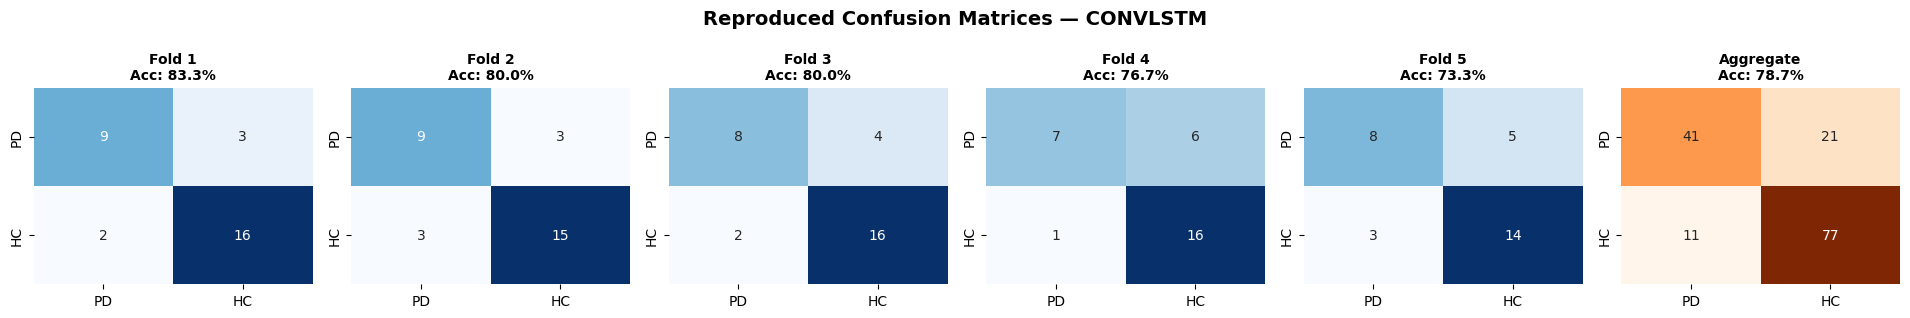


Reproducing VIT — mode=inference
  Fold 1: cache-match 100.0% [OK]

  --- Fold 1 ---
  N_val=30 | Acc=83.3%  Prec=81.0%  Rec=94.4%  F1=87.2%
  CM:           PD    Control
        PD      8     4
   Control      1    17
  Fold 2: cache-match 100.0% [OK]

  --- Fold 2 ---
  N_val=30 | Acc=86.7%  Prec=88.9%  Rec=88.9%  F1=88.9%
  CM:           PD    Control
        PD     10     2
   Control      2    16
  Fold 3: cache-match 100.0% [OK]

  --- Fold 3 ---
  N_val=30 | Acc=80.0%  Prec=80.0%  Rec=88.9%  F1=84.2%
  CM:           PD    Control
        PD      8     4
   Control      2    16
  Fold 4: cache-match 100.0% [OK]

  --- Fold 4 ---
  N_val=30 | Acc=83.3%  Prec=83.3%  Rec=88.2%  F1=85.7%
  CM:           PD    Control
        PD     10     3
   Control      2    15
  Fold 5: cache-match 100.0% [OK]

  --- Fold 5 ---
  N_val=30 | Acc=80.0%  Prec=78.9%  Rec=88.2%  F1=83.3%
  CM:           PD    Control
        PD      9     4
   Control      2    15

Reproduction Summary — VIT
  Fold  

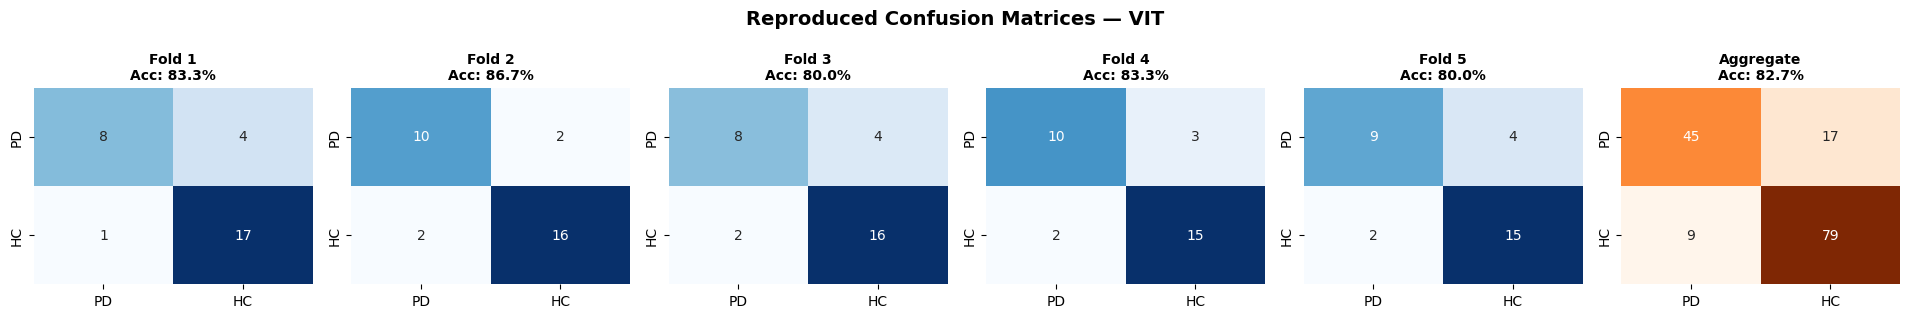

In [3]:
# ============================================================
# Reproduce Hybrid Gait PD Classification Results — STANDALONE
# Reads a saved model folder and reproduces all 5-fold metrics
# + confusion matrices from saved checkpoints.
#
# No dependency on the training script — model + dataset classes
# are redefined here.
#
# Usage:
#   Set MODEL_FOLDER below to your saved drive path, then run.
#
# Two modes:
#   - mode='inference' : reload weights + pre-normalized val data
#                        and re-run forward pass (default, verifies ckpts)
#   - mode='cached'    : load fold{k}_predictions.pkl directly
# ============================================================

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# CONFIGURATION — edit these
# ============================================================
MODEL_FOLDER = Path("/content/drive/MyDrive/gait_hybrid_16ch_models_new_lstm")   # ← your drive path
MODEL_TYPES  = ['convlstm', 'vit']                   # add 'flipflop' if trained
MODE         = 'inference'                           # 'inference' or 'cached'

N_FOLDS    = 5
BATCH_SIZE = 4
N_SENSORS  = 16
N_TIME     = 32
N_FREQ     = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device       : {DEVICE}")
print(f"Model folder : {MODEL_FOLDER.resolve()}")

# ============================================================
# DATASET
# ============================================================
class GaitDataset(Dataset):
    def __init__(self, X_sensors, X_spec, y):
        self.X_sensors = torch.FloatTensor(X_sensors)
        self.X_spec    = torch.FloatTensor(X_spec)
        self.y         = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_sensors[idx], self.X_spec[idx], self.y[idx]


# ============================================================
# MODEL COMPONENTS — must match training-time architecture exactly
# ============================================================
class SensorCNN(nn.Module):
    def __init__(self, n_sensors=N_SENSORS):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_sensors, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Dropout(0.15)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv3(x)
        return x.squeeze(-1)


class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(in_channels + hidden_channels,
                              4 * hidden_channels,
                              kernel_size, padding=kernel_size // 2)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c_prev + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        c_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t, c_t = self.cell(x[:, t], h_t, c_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.convlstm1 = ConvLSTM2D(N_SENSORS, 32, kernel_size=3, return_sequences=True)
        self.drop1     = nn.Dropout(0.15)
        self.convlstm2 = ConvLSTM2D(32, 16, kernel_size=3, return_sequences=False)
        self.drop2     = nn.Dropout(0.15)
        self.fc        = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.convlstm1(x))
        x = self.drop2(self.convlstm2(x))
        return self.fc(x)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        p = kernel_size // 2
        self.conv_xj = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hj = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)
        self.conv_xk = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hk = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)

    def forward(self, x, h_prev):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h_prev))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h_prev))
        return (1 - h_prev) * j + (1 - k) * h_prev


class FlipFlop2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = FlipFlopCell2D(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t = self.cell(x[:, t], h_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramFlipFlop(nn.Module):
    def __init__(self):
        super().__init__()
        self.ff1   = FlipFlop2D(N_SENSORS, 64, kernel_size=3, return_sequences=True)
        self.drop1 = nn.Dropout(0.15)
        self.ff2   = FlipFlop2D(64, 32, kernel_size=3, return_sequences=False)
        self.drop2 = nn.Dropout(0.15)
        self.fc    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.ff1(x))
        x = self.drop2(self.ff2(x))
        return self.fc(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class SpectrogramViT(nn.Module):
    def __init__(self, img_size=(N_TIME, N_FREQ), patch_size=4,
                 dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nt, nf    = img_size
        n_patches = (nt // patch_size) * (nf // patch_size)
        self.proj      = nn.Conv2d(N_SENSORS, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(nn.Linear(dim, 64), nn.ReLU())
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x   = x.permute(0, 3, 1, 2)
        x   = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed
        x   = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))


class HybridModel(nn.Module):
    def __init__(self, spec_model_type='convlstm'):
        super().__init__()
        self.sensor_cnn = SensorCNN()
        if spec_model_type == 'convlstm':
            self.spec_model = SpectrogramConvLSTM()
        elif spec_model_type == 'flipflop':
            self.spec_model = SpectrogramFlipFlop()
        elif spec_model_type == 'vit':
            self.spec_model = SpectrogramViT()
        else:
            raise ValueError(f"Unknown model type: {spec_model_type}")

        self.fusion = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 2)
        )

    def forward(self, x_sensors, x_spec):
        feat_sensors = self.sensor_cnn(x_sensors)
        feat_spec    = self.spec_model(x_spec)
        return self.fusion(torch.cat([feat_sensors, feat_spec], dim=1))


# ============================================================
# CORE REPRODUCTION
# ============================================================
def reproduce_fold(model_type, fold_idx, mode='inference'):
    """
    Reproduce a single fold's predictions.
      mode='inference' -> reload weights, re-run forward pass on saved val data
      mode='cached'    -> load fold{k}_predictions.pkl directly
    Returns: (preds, labels)
    """
    model_dir = MODEL_FOLDER / model_type
    fold_num  = fold_idx + 1

    if mode == 'cached':
        pred_path = model_dir / f"fold{fold_num}_predictions.pkl"
        if not pred_path.exists():
            raise FileNotFoundError(f"Missing {pred_path}")
        with open(pred_path, 'rb') as f:
            d = pickle.load(f)
        return np.array(d['predictions']), np.array(d['true_labels'])

    # mode == 'inference'
    test_path = model_dir / f"fold{fold_num}_test_data.pkl"
    ckpt_path = model_dir / f"fold{fold_num}_best.pth"

    if not test_path.exists():
        raise FileNotFoundError(f"Missing {test_path}")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing {ckpt_path}")

    with open(test_path, 'rb') as f:
        fd = pickle.load(f)

    # Val tensors are already normalized (training code stored them post-norm)
    X_sensors_val = fd['X_sensors_val']
    X_spec_val    = fd['X_spec_val']
    y_val         = fd['y_val']

    loader = DataLoader(GaitDataset(X_sensors_val, X_spec_val, y_val),
                        batch_size=BATCH_SIZE, shuffle=False)

    model = HybridModel(spec_model_type=model_type).to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_sensors, x_spec, yb in loader:
            x_sensors = x_sensors.to(DEVICE)
            x_spec    = x_spec.to(DEVICE)
            out       = model(x_sensors, x_spec)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())

    return np.array(all_preds), np.array(all_labels)


def reproduce_all_folds(model_type, mode='inference', verify_against_cache=True):
    """
    Reproduce every fold for a given model type.
    """
    print(f"\n{'='*65}")
    print(f"Reproducing {model_type.upper()} — mode={mode}")
    print(f"{'='*65}")

    model_dir = MODEL_FOLDER / model_type
    if not model_dir.exists():
        raise FileNotFoundError(f"No model dir: {model_dir}")

    fold_metrics, all_preds, all_labels = [], [], []

    for fold in range(N_FOLDS):
        preds, labels = reproduce_fold(model_type, fold, mode=mode)

        # Cross-check inference vs cached predictions
        if mode == 'inference' and verify_against_cache:
            cache_path = model_dir / f"fold{fold+1}_predictions.pkl"
            if cache_path.exists():
                with open(cache_path, 'rb') as f:
                    cached = pickle.load(f)
                cached_preds = np.array(cached['predictions'])
                if len(cached_preds) == len(preds):
                    match = (cached_preds == preds).mean() * 100
                    flag  = "OK" if match == 100.0 else "WARN"
                    print(f"  Fold {fold+1}: cache-match {match:.1f}% [{flag}]")
                else:
                    print(f"  Fold {fold+1}: cache size mismatch "
                          f"(cached={len(cached_preds)}, reproduced={len(preds)})")

        acc  = accuracy_score(labels, preds)
        prec = precision_score(labels, preds, zero_division=0)
        rec  = recall_score(labels, preds, zero_division=0)
        f1   = f1_score(labels, preds, zero_division=0)

        fold_metrics.append({'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})
        all_preds.extend(preds)
        all_labels.extend(labels)

        cm = confusion_matrix(labels, preds)
        print(f"\n  --- Fold {fold+1} ---")
        print(f"  N_val={len(labels)} | Acc={acc*100:.1f}%  "
              f"Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  F1={f1*100:.1f}%")
        print(f"  CM:           PD    Control")
        print(f"        PD   {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"   Control   {cm[1,0]:4d}  {cm[1,1]:4d}")

    return {
        'metrics':    fold_metrics,
        'all_preds':  np.array(all_preds),
        'all_labels': np.array(all_labels),
    }


# ============================================================
# SUMMARY + PLOTTING
# ============================================================
def print_summary(results, model_type):
    print(f"\n{'='*55}")
    print(f"Reproduction Summary — {model_type.upper()}")
    print(f"{'='*55}")
    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for i, m in enumerate(results['metrics']):
        print(f"  {i+1:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")
    accs = [m['acc']  for m in results['metrics']]
    pres = [m['prec'] for m in results['metrics']]
    recs = [m['rec']  for m in results['metrics']]
    f1s  = [m['f1']   for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(pres)*100:>7.1f}% "
          f"{np.mean(recs)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}%  {np.std(pres)*100:>7.1f}%  "
          f"{np.std(recs)*100:>7.1f}%  {np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(results, model_type, save_dir=None):
    """Per-fold + aggregate confusion matrices."""
    fig, axes = plt.subplots(1, N_FOLDS + 1, figsize=(3.2 * (N_FOLDS + 1), 3.2))
    fig.suptitle(f'Reproduced Confusion Matrices — {model_type.upper()}',
                 fontsize=14, fontweight='bold')

    start = 0
    for fold in range(N_FOLDS):
        # Read fold's val size from saved test_data (robust to RNG drift)
        with open(MODEL_FOLDER / model_type / f"fold{fold+1}_test_data.pkl", 'rb') as f:
            n_val = len(pickle.load(f)['y_val'])
        end = start + n_val

        cm = confusion_matrix(results['all_labels'][start:end],
                              results['all_preds'][start:end])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[fold],
                    cbar=False, xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
        axes[fold].set_title(f"Fold {fold+1}\nAcc: {results['metrics'][fold]['acc']*100:.1f}%",
                             fontsize=10, fontweight='bold')
        start = end

    cm_all  = confusion_matrix(results['all_labels'], results['all_preds'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=axes[-1],
                cbar=False, xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
    axes[-1].set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%",
                       fontsize=10, fontweight='bold')

    plt.tight_layout()
    if save_dir is not None:
        out = Path(save_dir) / f"{model_type}_reproduced_cm.png"
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Saved: {out}")
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    for mt in MODEL_TYPES:
        try:
            results = reproduce_all_folds(mt, mode=MODE, verify_against_cache=True)
            print_summary(results, mt)
            plot_confusion_matrices(results, mt, save_dir=MODEL_FOLDER)
        except FileNotFoundError as e:
            print(f"\n[SKIP] {mt}: {e}")

Device       : cuda
Model folder : /content/drive/MyDrive/gait_hybrid_16ch_models_new

Reproducing FLIPFLOP — mode=inference
  Fold 1: cache-match 100.0% [OK]

  --- Fold 1 ---
  N_val=30 | Acc=93.3%  Prec=94.4%  Rec=94.4%  F1=94.4%
  CM:           PD    Control
        PD     11     1
   Control      1    17
  Fold 2: cache-match 100.0% [OK]

  --- Fold 2 ---
  N_val=30 | Acc=86.7%  Prec=93.8%  Rec=83.3%  F1=88.2%
  CM:           PD    Control
        PD     11     1
   Control      3    15
  Fold 3: cache-match 100.0% [OK]

  --- Fold 3 ---
  N_val=30 | Acc=83.3%  Prec=88.2%  Rec=83.3%  F1=85.7%
  CM:           PD    Control
        PD     10     2
   Control      3    15
  Fold 4: cache-match 100.0% [OK]

  --- Fold 4 ---
  N_val=30 | Acc=83.3%  Prec=83.3%  Rec=88.2%  F1=85.7%
  CM:           PD    Control
        PD     10     3
   Control      2    15
  Fold 5: cache-match 100.0% [OK]

  --- Fold 5 ---
  N_val=30 | Acc=80.0%  Prec=82.4%  Rec=82.4%  F1=82.4%
  CM:           PD    C

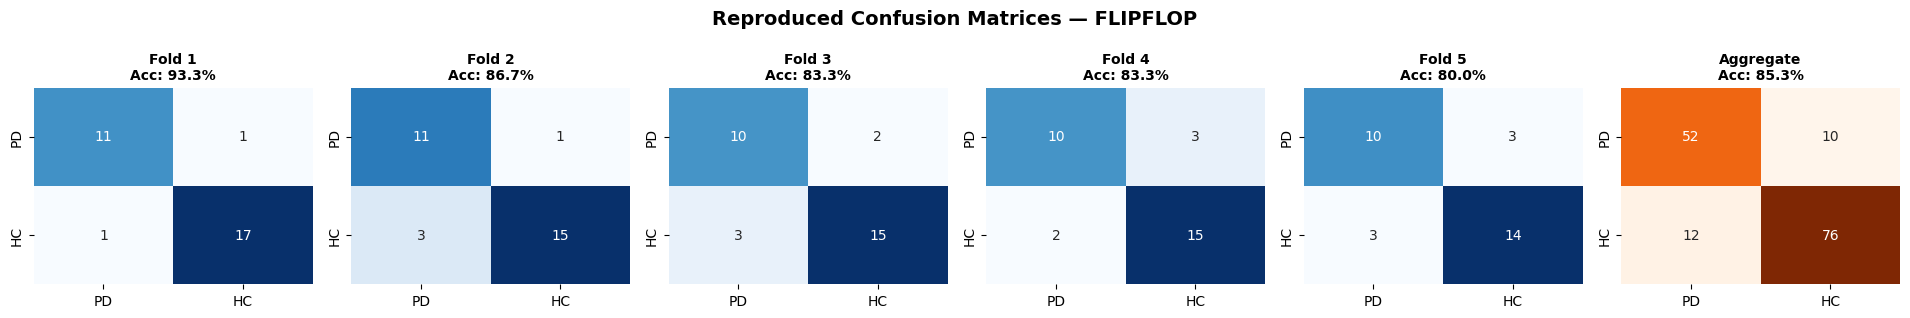

In [5]:
# ============================================================
# Reproduce Hybrid Gait PD Classification Results — STANDALONE
# Reads a saved model folder and reproduces all 5-fold metrics
# + confusion matrices from saved checkpoints.
#
# No dependency on the training script — model + dataset classes
# are redefined here.
#
# Usage:
#   Set MODEL_FOLDER below to your saved drive path, then run.
#
# Two modes:
#   - mode='inference' : reload weights + pre-normalized val data
#                        and re-run forward pass (default, verifies ckpts)
#   - mode='cached'    : load fold{k}_predictions.pkl directly
# ============================================================

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# CONFIGURATION — edit these
# ============================================================
MODEL_FOLDER = Path("/content/drive/MyDrive/gait_hybrid_16ch_models_new")   # ← your drive path
MODEL_TYPES  = ['flipflop']                   # add 'flipflop' if trained
MODE         = 'inference'                           # 'inference' or 'cached'

N_FOLDS    = 5
BATCH_SIZE = 4
N_SENSORS  = 16
N_TIME     = 32
N_FREQ     = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device       : {DEVICE}")
print(f"Model folder : {MODEL_FOLDER.resolve()}")

# ============================================================
# DATASET
# ============================================================
class GaitDataset(Dataset):
    def __init__(self, X_sensors, X_spec, y):
        self.X_sensors = torch.FloatTensor(X_sensors)
        self.X_spec    = torch.FloatTensor(X_spec)
        self.y         = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_sensors[idx], self.X_spec[idx], self.y[idx]


# ============================================================
# MODEL COMPONENTS — must match training-time architecture exactly
# ============================================================
class SensorCNN(nn.Module):
    def __init__(self, n_sensors=N_SENSORS):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_sensors, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Dropout(0.15)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv3(x)
        return x.squeeze(-1)


class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(in_channels + hidden_channels,
                              4 * hidden_channels,
                              kernel_size, padding=kernel_size // 2)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c_prev + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        c_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t, c_t = self.cell(x[:, t], h_t, c_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.convlstm1 = ConvLSTM2D(N_SENSORS, 32, kernel_size=3, return_sequences=True)
        self.drop1     = nn.Dropout(0.15)
        self.convlstm2 = ConvLSTM2D(32, 16, kernel_size=3, return_sequences=False)
        self.drop2     = nn.Dropout(0.15)
        self.fc        = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.convlstm1(x))
        x = self.drop2(self.convlstm2(x))
        return self.fc(x)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        p = kernel_size // 2
        self.conv_xj = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hj = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)
        self.conv_xk = nn.Conv2d(in_channels,     hidden_channels, kernel_size, padding=p)
        self.conv_hk = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=p)

    def forward(self, x, h_prev):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h_prev))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h_prev))
        return (1 - h_prev) * j + (1 - k) * h_prev


class FlipFlop2D(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequences=False):
        super().__init__()
        self.hidden_channels  = hidden_channels
        self.return_sequences = return_sequences
        self.cell = FlipFlopCell2D(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        batch, time_steps, _, h, w = x.size()
        h_t = torch.zeros(batch, self.hidden_channels, h, w, device=x.device)
        outputs = []
        for t in range(time_steps):
            h_t = self.cell(x[:, t], h_t)
            outputs.append(h_t)
        return torch.stack(outputs, dim=1) if self.return_sequences else h_t


class SpectrogramFlipFlop(nn.Module):
    def __init__(self):
        super().__init__()
        self.ff1   = FlipFlop2D(N_SENSORS, 64, kernel_size=3, return_sequences=True)
        self.drop1 = nn.Dropout(0.15)
        self.ff2   = FlipFlop2D(64, 32, kernel_size=3, return_sequences=False)
        self.drop2 = nn.Dropout(0.15)
        self.fc    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * N_FREQ, 64),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 1, 3, 2).unsqueeze(-1)
        x = self.drop1(self.ff1(x))
        x = self.drop2(self.ff2(x))
        return self.fc(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class SpectrogramViT(nn.Module):
    def __init__(self, img_size=(N_TIME, N_FREQ), patch_size=4,
                 dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nt, nf    = img_size
        n_patches = (nt // patch_size) * (nf // patch_size)
        self.proj      = nn.Conv2d(N_SENSORS, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(nn.Linear(dim, 64), nn.ReLU())
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x   = x.permute(0, 3, 1, 2)
        x   = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed
        x   = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))


class HybridModel(nn.Module):
    def __init__(self, spec_model_type='convlstm'):
        super().__init__()
        self.sensor_cnn = SensorCNN()
        if spec_model_type == 'convlstm':
            self.spec_model = SpectrogramConvLSTM()
        elif spec_model_type == 'flipflop':
            self.spec_model = SpectrogramFlipFlop()
        elif spec_model_type == 'vit':
            self.spec_model = SpectrogramViT()
        else:
            raise ValueError(f"Unknown model type: {spec_model_type}")

        self.fusion = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 2)
        )

    def forward(self, x_sensors, x_spec):
        feat_sensors = self.sensor_cnn(x_sensors)
        feat_spec    = self.spec_model(x_spec)
        return self.fusion(torch.cat([feat_sensors, feat_spec], dim=1))


# ============================================================
# CORE REPRODUCTION
# ============================================================
def reproduce_fold(model_type, fold_idx, mode='inference'):
    """
    Reproduce a single fold's predictions.
      mode='inference' -> reload weights, re-run forward pass on saved val data
      mode='cached'    -> load fold{k}_predictions.pkl directly
    Returns: (preds, labels)
    """
    model_dir = MODEL_FOLDER / model_type
    fold_num  = fold_idx + 1

    if mode == 'cached':
        pred_path = model_dir / f"fold{fold_num}_predictions.pkl"
        if not pred_path.exists():
            raise FileNotFoundError(f"Missing {pred_path}")
        with open(pred_path, 'rb') as f:
            d = pickle.load(f)
        return np.array(d['predictions']), np.array(d['true_labels'])

    # mode == 'inference'
    test_path = model_dir / f"fold{fold_num}_test_data.pkl"
    ckpt_path = model_dir / f"fold{fold_num}_best.pth"

    if not test_path.exists():
        raise FileNotFoundError(f"Missing {test_path}")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing {ckpt_path}")

    with open(test_path, 'rb') as f:
        fd = pickle.load(f)

    # Val tensors are already normalized (training code stored them post-norm)
    X_sensors_val = fd['X_sensors_val']
    X_spec_val    = fd['X_spec_val']
    y_val         = fd['y_val']

    loader = DataLoader(GaitDataset(X_sensors_val, X_spec_val, y_val),
                        batch_size=BATCH_SIZE, shuffle=False)

    model = HybridModel(spec_model_type=model_type).to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_sensors, x_spec, yb in loader:
            x_sensors = x_sensors.to(DEVICE)
            x_spec    = x_spec.to(DEVICE)
            out       = model(x_sensors, x_spec)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())

    return np.array(all_preds), np.array(all_labels)


def reproduce_all_folds(model_type, mode='inference', verify_against_cache=True):
    """
    Reproduce every fold for a given model type.
    """
    print(f"\n{'='*65}")
    print(f"Reproducing {model_type.upper()} — mode={mode}")
    print(f"{'='*65}")

    model_dir = MODEL_FOLDER / model_type
    if not model_dir.exists():
        raise FileNotFoundError(f"No model dir: {model_dir}")

    fold_metrics, all_preds, all_labels = [], [], []

    for fold in range(N_FOLDS):
        preds, labels = reproduce_fold(model_type, fold, mode=mode)

        # Cross-check inference vs cached predictions
        if mode == 'inference' and verify_against_cache:
            cache_path = model_dir / f"fold{fold+1}_predictions.pkl"
            if cache_path.exists():
                with open(cache_path, 'rb') as f:
                    cached = pickle.load(f)
                cached_preds = np.array(cached['predictions'])
                if len(cached_preds) == len(preds):
                    match = (cached_preds == preds).mean() * 100
                    flag  = "OK" if match == 100.0 else "WARN"
                    print(f"  Fold {fold+1}: cache-match {match:.1f}% [{flag}]")
                else:
                    print(f"  Fold {fold+1}: cache size mismatch "
                          f"(cached={len(cached_preds)}, reproduced={len(preds)})")

        acc  = accuracy_score(labels, preds)
        prec = precision_score(labels, preds, zero_division=0)
        rec  = recall_score(labels, preds, zero_division=0)
        f1   = f1_score(labels, preds, zero_division=0)

        fold_metrics.append({'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})
        all_preds.extend(preds)
        all_labels.extend(labels)

        cm = confusion_matrix(labels, preds)
        print(f"\n  --- Fold {fold+1} ---")
        print(f"  N_val={len(labels)} | Acc={acc*100:.1f}%  "
              f"Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  F1={f1*100:.1f}%")
        print(f"  CM:           PD    Control")
        print(f"        PD   {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"   Control   {cm[1,0]:4d}  {cm[1,1]:4d}")

    return {
        'metrics':    fold_metrics,
        'all_preds':  np.array(all_preds),
        'all_labels': np.array(all_labels),
    }


# ============================================================
# SUMMARY + PLOTTING
# ============================================================
def print_summary(results, model_type):
    print(f"\n{'='*55}")
    print(f"Reproduction Summary — {model_type.upper()}")
    print(f"{'='*55}")
    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for i, m in enumerate(results['metrics']):
        print(f"  {i+1:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")
    accs = [m['acc']  for m in results['metrics']]
    pres = [m['prec'] for m in results['metrics']]
    recs = [m['rec']  for m in results['metrics']]
    f1s  = [m['f1']   for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(pres)*100:>7.1f}% "
          f"{np.mean(recs)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}%  {np.std(pres)*100:>7.1f}%  "
          f"{np.std(recs)*100:>7.1f}%  {np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(results, model_type, save_dir=None):
    """Per-fold + aggregate confusion matrices."""
    fig, axes = plt.subplots(1, N_FOLDS + 1, figsize=(3.2 * (N_FOLDS + 1), 3.2))
    fig.suptitle(f'Reproduced Confusion Matrices — {model_type.upper()}',
                 fontsize=14, fontweight='bold')

    start = 0
    for fold in range(N_FOLDS):
        # Read fold's val size from saved test_data (robust to RNG drift)
        with open(MODEL_FOLDER / model_type / f"fold{fold+1}_test_data.pkl", 'rb') as f:
            n_val = len(pickle.load(f)['y_val'])
        end = start + n_val

        cm = confusion_matrix(results['all_labels'][start:end],
                              results['all_preds'][start:end])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[fold],
                    cbar=False, xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
        axes[fold].set_title(f"Fold {fold+1}\nAcc: {results['metrics'][fold]['acc']*100:.1f}%",
                             fontsize=10, fontweight='bold')
        start = end

    cm_all  = confusion_matrix(results['all_labels'], results['all_preds'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=axes[-1],
                cbar=False, xticklabels=['PD', 'HC'], yticklabels=['PD', 'HC'])
    axes[-1].set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%",
                       fontsize=10, fontweight='bold')

    plt.tight_layout()
    if save_dir is not None:
        out = Path(save_dir) / f"{model_type}_reproduced_cm.png"
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Saved: {out}")
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    for mt in MODEL_TYPES:
        try:
            results = reproduce_all_folds(mt, mode=MODE, verify_against_cache=True)
            print_summary(results, mt)
            plot_confusion_matrices(results, mt, save_dir=MODEL_FOLDER)
        except FileNotFoundError as e:
            print(f"\n[SKIP] {mt}: {e}")